# Model Setup and Loading

Before we start looking at how the logit lens and tuned lens work, we need to choose the model we’ll be working with. In this project, we’re using GPT-2 because of its simplicity. In the `src` folder, there’s a directory called `model_utils`, which contains a specific function called `load_model_and_tokenizer` to load the model and its tokenizer. 

In [2]:
import sys

# Add project root in the path
sys.path.append('..')

In [3]:
from src.model_utils import load_model_and_tokenizer

model, tokenizer = load_model_and_tokenizer('gpt2')

d:\Deep Learning - Github\logit-lens-vs-tuned-lens\logit-lens-vs-tuned-lens\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 11382.31it/s]


# Baseline

In this section, we'll use the text “The sky is usually,” and we expect the model to predict “blue”. First, let's verify that the model we imported—in this case, GPT-2—actually makes this prediction.

In [4]:
prompt = 'The sky is usually'

In [5]:
import torch

# Tokenizer the input
inputs = tokenizer(prompt, return_tensors='pt')

with torch.no_grad():
    output = model(**inputs)
    
logits = output.logits
next_token_logits = logits[:, -1, :] # Take last token
next_token_id = torch.argmax(next_token_logits, dim=-1) # Most probably token

next_word = tokenizer.decode(next_token_id)

print(f'Next token prediction: {next_word}')

Next token prediction:  blue


# Logit Lens

Consider a Transformer with $L$ layers. In a forward pass, for a token at position $i$, the model produces a sequence of hidden states
$$
h_{0}^{(i)}, h_{1}^{(i)}, ..., h_{L}^{(i)}
$$
with $h_{l}^{(i)} \in \mathbb{R}^{d}$, where $d$ is the state dimension and $l$ is the layer.

In the last layer, the model generates its prediction for the next token as follows:
$$
z_{L}^{(i)} = W_U \cdot \text{LayerNorm}(h_{L}^{(i)}) \\
p_{l}^{(i)} = \text{Softmax}(z_{L}^{(i)})
$$
where $W_U \in \mathbb{R}^{V \times d}$ is the embedding matrix, and $V$ is the vocabulary size.

The Logit Lens technique consists of applying this same operation to an intermediate hidden state $h_{l}^{(i)}$, where $l < L$.

Now that we understand the concept behind the Logit Lens, let’s see what happens internally in the hidden states as they try to predict the next token in our baseline, where we already know that the final prediction is “blue”.

In [6]:
from src.logit_lens import run_logit_lens
from src.notebooks_utils import get_word_probability

# Get prediction of all layers
layers_predictions_logit = run_logit_lens(model, tokenizer, prompt, top_k=10)

# Get probability that the word is "blue"
probs_logit = get_word_probability(layers_predictions_logit, 'blue')

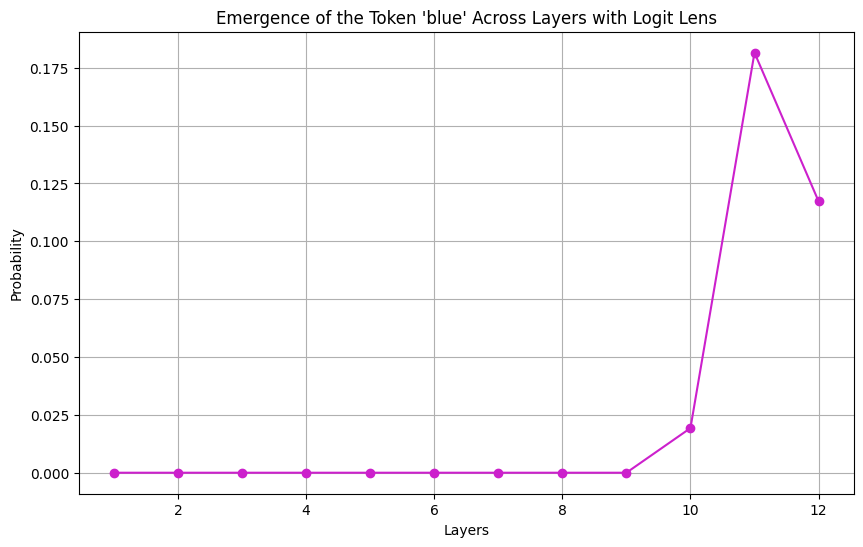

In [ ]:
import matplotlib.pyplot as plt

# Graph
plt.figure(figsize=(10, 6))

plt.plot(range(1, len(probs_logit) + 1), probs_logit, marker='o', color="#cc20cc")

plt.title('Emergence of the Token \'blue\' Across Layers with Logit Lens')
plt.xlabel('Layers')
plt.ylabel('Probability')

plt.grid()
plt.show()

In this graph, we can see that the word “blue” begins to appear in the top 10 most likely tokens starting from layer 10.

Now let's see how Tuned Lens improves this and why it helps us better understand what happens internally in each layer.

# Tuned Lens

The main problem with the Logit Lens is that the feature space of the hidden layers is not necessarily aligned with the feature space of the final layer.

To solve this problem, the Tuned Lens introduces an affine transformation for each layer $l$. The idea is to project the hidden state $h_{l}^{(i)}$ onto a new vector $\~{h}_{l}^{(i)}$ that simulates being in the feature space of the final layer.
$$
\~{h}_{l}^{(i)} = A_l h_{l}^{(i)} + b_l,
$$
where $A_l \in \mathbb{R}^{d \times d}$ is a weight matrix and $b_l \in \mathbb{R}^d$ is a bias vector.

Note: If the matrix $A_l$ is the identity matrix and $b_l$ is zero, then this is exactly $h_{l}^{(i)}$, meaning we would have a Logit Lens.

To train the parameters $A_l$ and $b_l$ for each layer, we must freeze the weights of the model we are going to use—for example, GPT-2 in this project—and train the parameters by minimizing the Kullback-Leibler divergence
$$
D_{\text{KL}}(P || Q) = \sum_i P(i) \ln{\frac{P(i)}{Q(i)}},
$$
between the predictions of the intermediate lens and the actual predictions of the final model.

In [8]:
from src.tuned_lens import run_tuned_lens, SingleLayerTunedLens

device = "cpu"
print(f'Device: {device}')

hidden_size = model.config.n_embd
num_layers = model.config.n_layer

# Structure from lenses
lenses = torch.nn.ModuleDict({
    str(layer_idx): SingleLayerTunedLens(hidden_size)
    for layer_idx in range(1, num_layers)
})

# Load weights saved
lenses.load_state_dict(torch.load('..\checkpoints/all_tuned_lenses.pt', map_location=device))
lenses.to(device)

lenses.eval()

layers_predictions_tuned = run_tuned_lens(model, tokenizer, lenses, prompt, top_k=10, device=device)

# Get probability that the word is "blue"
probs_tuned = get_word_probability(layers_predictions_tuned, 'blue')

Device: cpu


C:\Users\Jako\AppData\Local\Temp\ipykernel_9852\3383439886.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  lenses.load_state_dict(torch.load('..\checkpoints/all_tuned_l

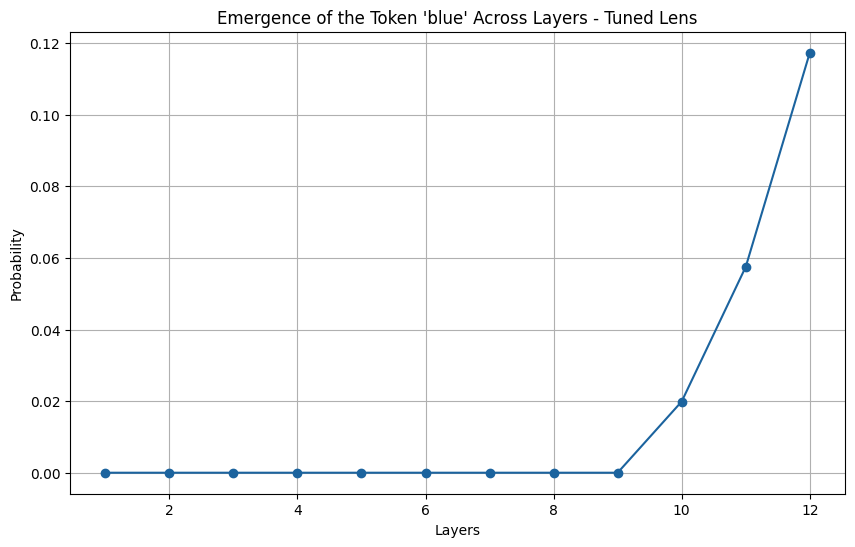

In [ ]:
# Graph
plt.figure(figsize=(10, 6))

plt.plot(range(1, len(probs_tuned) + 1), probs_tuned, marker='o', color="#1B639E")

plt.title('Emergence of the Token \'blue\' Across Layers - Tuned Lens')
plt.xlabel('Layers')
plt.ylabel('Probability')

plt.grid()
plt.show()

In the case of the word “blue”, it appears in the top 10 starting from layer 10 in both the Logit Lens and the Tuned Lens. To better illustrate the difference between the two techniques, the following section shows other words that appear in the top 10 of the model's possible predictions.

# Visual Comparation

As mentioned at the end of the previous section, here we’re going to use different terms to see what happens across the layers and how their probabilities change. Specifically, we’ll use the following terms: “dark,” “bright,” “a,” and “blue.”

In [10]:
probs_dark_logit = get_word_probability(layers_predictions_logit, 'dark')
probs_dark_tuned = get_word_probability(layers_predictions_tuned, 'dark')

probs_bright_logit = get_word_probability(layers_predictions_logit, 'bright')
probs_bright_tuned = get_word_probability(layers_predictions_tuned, 'bright')

probs_a_logit = get_word_probability(layers_predictions_logit, 'a')
probs_a_tuned = get_word_probability(layers_predictions_tuned, 'a')

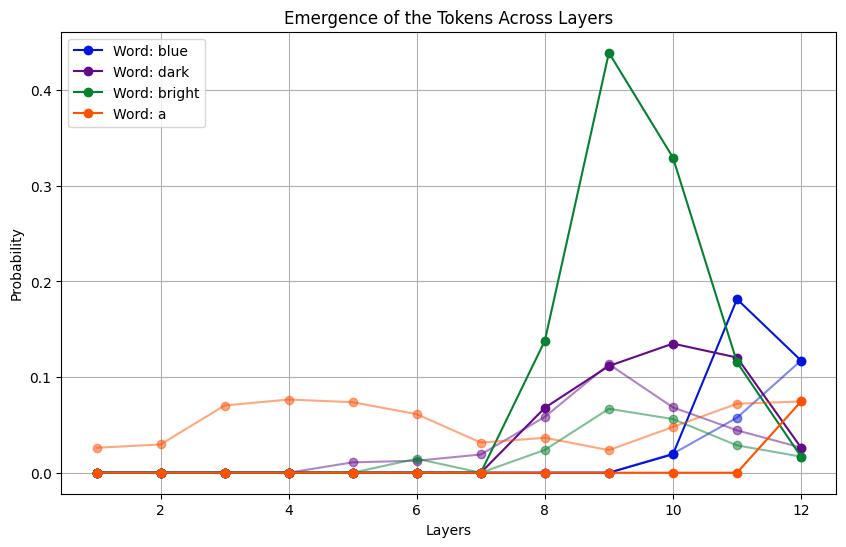

In [ ]:
# Graph
plt.figure(figsize=(10, 6))

plt.plot(range(1, len(probs_logit) + 1), probs_logit, marker='o', color="#0016DD", label='Word: blue')
plt.plot(range(1, len(probs_tuned) + 1), probs_tuned, marker='o', color="#0016DD", alpha=0.5)

plt.plot(range(1, len(probs_dark_logit) + 1), probs_dark_logit, marker='o', color="#640A88", label='Word: dark')
plt.plot(range(1, len(probs_dark_tuned) + 1), probs_dark_tuned, marker='o', color="#640A88", alpha=0.5)

plt.plot(range(1, len(probs_bright_logit) + 1), probs_bright_logit, marker='o', color="#05812F", label='Word: bright')
plt.plot(range(1, len(probs_bright_tuned) + 1), probs_bright_tuned, marker='o', color="#05812F", alpha=0.5)

plt.plot(range(1, len(probs_a_logit) + 1), probs_a_logit, marker='o', color="#FF5100", label='Word: a')
plt.plot(range(1, len(probs_a_tuned) + 1), probs_a_tuned, marker='o', color="#FF5100", alpha=0.5)

plt.title('Emergence of the Tokens Across Layers')
plt.xlabel('Layers')
plt.ylabel('Probability')

plt.grid()
plt.legend(loc='upper left')
plt.show()

To understand this graph, you need to know that lines of the same color represent the same word, but the one with a solid color is the Logit Lens, and the one that is more transparent is the Tuned Lens.

This graph helps us see how the Tuned Lens reveals relevant information from the first layers that we would never have obtained using only the Logit Lens.